In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# ============================================================
# Fixed parameters
# ============================================================
omega = np.array([0.5, 1, 1])   # (w1, w2, w3)
#omega = np.array([0.3028,0,0.3162])
A = -1.0
B = 1.0
sigma = 1.0

M = 1.0
N_cost = 1.0
lambda_reg = 0.1

ridge = 0


# ============================================================
# Helpers
# ============================================================
def exact_discrete_coeffs(dt, A=-1.0, B=1.0, sigma=0.1):
    """
    Continuous-time dynamics:
        ds = (A s + B a) dt + sigma dW

    Exact one-step form:
        s_{n+1} = exp(A dt) s_n + G_a a_n + noise

    Also return PhiBE coefficients:
        s_{n+1} = s_n + dt * (A_t s_n + B_t a_n) + eps
        Var(eps) = sigma_t2 * dt
    """
    if abs(A) < 1e-12:
        expA = 1.0
        G_a = B * dt
        var_noise = sigma**2 * dt

        A_t = 0.0
        B_t = B
        sigma_t2 = sigma**2
    else:
        expA = np.exp(A * dt)
        G_a = B * (expA - 1.0) / A
        var_noise = sigma**2 * (np.exp(2.0 * A * dt) - 1.0) / (2.0 * A)

        A_t = (expA - 1.0) / dt
        B_t = G_a / dt
        sigma_t2 = var_noise / dt

    return expA, G_a, var_noise, A_t, B_t, sigma_t2


def sample_action(s, rng, omega):
    w1, w2, w3 = omega
    return rng.normal(loc=w1 * s + w2, scale=w3)


def log_gaussian_policy(a, s, omega):
    w1, w2, w3 = omega
    mu = w1 * s + w2
    return -0.5 * np.log(2.0 * np.pi) - np.log(w3) - 0.5 * ((a - mu) / w3) ** 2


def basis(s):
    s = np.asarray(s)
    return np.column_stack([
        np.ones_like(s) / beta,
        s,
        s**2,
    ])


def basis_prime(s):
    s = np.asarray(s)
    return np.column_stack([
        np.zeros_like(s),
        np.ones_like(s),
        2.0 * s,
    ])


def basis_second(s):
    s = np.asarray(s)
    return np.column_stack([
        np.zeros_like(s),
        np.zeros_like(s),
        2.0 * np.ones_like(s),
    ])


def value_from_theta(s, theta):
    s = np.asarray(s)
    return theta[0] / beta + theta[1] * s + theta[2] * s**2

In [7]:
# ============================================================
# Exact PhiBE target V_{dt} under fixed Gaussian policy
# ============================================================
def true_k_dt_under_fixed_policy(
    beta,
    dt,
    omega,
    A=-1.0,
    B=1.0,
    sigma=0.1,
    M=1.0,
    N_cost=1.0,
    lambda_reg=0.1,
):
    """
    Closed-form PhiBE target:
    plug A_t, B_t, sigma_t2 directly into the value-function formula
    """
    w1, w2, w3 = omega
    _, _, _, A_t, B_t, sigma_t2 = exact_discrete_coeffs(dt, A=A, B=B, sigma=sigma)

    entropy_const = 0.5 * np.log(2.0 * np.pi) + np.log(w3) + 0.5

    denom2 = beta - 2.0 * (A_t + B_t * w1)
    denom1 = beta - (A_t + B_t * w1)

    if abs(denom2) < 1e-12:
        raise ValueError(f"denom2 too small: {denom2}")
    if abs(denom1) < 1e-12:
        raise ValueError(f"denom1 too small: {denom1}")

    k2 = -(M + N_cost * w1**2) / denom2
    k1 = (B_t * w2 * k2 - N_cost * w1 * w2) / denom1
    k0 = -0.5 * N_cost * (w2**2 + w3**2) + lambda_reg * entropy_const + B_t * w2 * k1 + 0.5 * sigma_t2 * k2

    # radicand = (A_t - 0.5 * beta) ** 2 + (M * B_t**2) / N_cost
    # sqrt_term = np.sqrt(radicand)

    # k2 = (N_cost / (B_t**2)) * (0.5 * beta - A_t - sqrt_term)
    # k1 = 0.0
    # k0 = -(lambda_reg / (2.0 * beta)) * np.log(N_cost / (2.0 * np.pi * lambda_reg)) \
    #           + (sigma_t2 / (2.0 * beta)) * k2

    return k2, k1, k0


def value_true_dt(
    s,
    beta,
    dt,
    omega,
    A=-1.0,
    B=1.0,
    sigma=0.5,
    M=1.0,
    N_cost=1.0,
    lambda_reg=0.1,
):
    k2, k1, k0 = true_k_dt_under_fixed_policy(
        beta=beta,
        dt=dt,
        omega=omega,
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N_cost=N_cost,
        lambda_reg=lambda_reg,
    )
    s = np.asarray(s)
    return 0.5 * k2 * s**2 + k1 * s + k0 / beta


# ============================================================
# Sample PhiBE estimator V_N
# ============================================================
def fit_theta_phibe_sample(
    s,
    a,
    s_next,
    beta,
    dt,
    omega,
    A=-1.0,
    B=1.0,
    sigma=0.5,
    M=1.0,
    N_cost=1.0,
    lambda_reg=0.1,
    ridge=1e-8,
):
    """
    Sample PhiBE:
        A_N = mean phi(s) [ beta phi(s) - (Delta s / dt) phi'(s) - 0.5 sigma_t2 phi''(s) ]^T
        b_N = mean phi(s) r(s,a,pi,lambda)
    """
    _, _, _, _, _, sigma_t2 = exact_discrete_coeffs(dt, A=A, B=B, sigma=sigma)

    phi = basis(s)
    phi_p = basis_prime(s)
    phi_pp = basis_second(s)

    delta_over_dt = (s_next - s) / dt
    #op = beta * phi - delta_over_dt[:, None] * phi_p - 0.5 * sigma_t2 * phi_pp
    op = beta * phi - delta_over_dt[:, None] * phi_p

    logp = log_gaussian_policy(a, s, omega)
    reward = -0.5 * M * s**2 - 0.5 * N_cost * a**2 - lambda_reg * logp

    A_hat = phi.T @ op / len(s)
    b_hat = phi.T @ reward / len(s)

    A_hat = A_hat + ridge * np.eye(3)
    theta_hat = np.linalg.solve(A_hat, b_hat)

    return theta_hat


def simulate_on_policy_data(
    N_sample,
    dt,
    omega,
    A=-1.0,
    B=1.0,
    sigma=0.5,
    s0=0.0,
    burn_in=300,
    seed=0,
):
    rng = np.random.default_rng(seed)

    expA, G_a, var_noise, _, _, _ = exact_discrete_coeffs(dt, A=A, B=B, sigma=sigma)

    s = float(s0)

    for _ in range(burn_in):
        a = sample_action(s, rng, omega)
        eps = rng.normal(loc=0.0, scale=np.sqrt(var_noise))
        s = expA * s + G_a * a + eps

    s_list = np.zeros(N_sample)
    a_list = np.zeros(N_sample)
    s_next_list = np.zeros(N_sample)

    for i in range(N_sample):
        a = sample_action(s, rng, omega)
        eps = rng.normal(loc=0.0, scale=np.sqrt(var_noise))
        s_next = expA * s + G_a * a + eps

        s_list[i] = s
        a_list[i] = a
        s_next_list[i] = s_next

        s = s_next

    return s_list, a_list, s_next_list


In [9]:
# ============================================================
# (1) Function to compute error for one setting
# ============================================================
def compute_error_for_one_setting(
    beta,
    dt,
    N_sample,
    n_rep=30,
    omega=np.array([0.5, 1.0, 1.0]),
    A=-1.0,
    B=1.0,
    sigma=0.1,
    M=1.0,
    N_cost=1.0,
    lambda_reg=0.1,
    ridge=1e-8,
    s_eval=None,
    base_seed=12345,
):
    """
    Return:
        error_mean, error_std
    where error = ||V_N - V_{dt}|| on an evaluation grid
    """
    if s_eval is None:
        s_eval = np.linspace(-4.0, 4.0, 401)

    V_dt_eval = value_true_dt(
        s_eval,
        beta=beta,
        dt=dt,
        omega=omega,
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N_cost=N_cost,
        lambda_reg=lambda_reg,
    )

    k2, k1, k0 = true_k_dt_under_fixed_policy(
        beta=beta,
        dt=dt,
        omega=omega,
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N_cost=N_cost,
        lambda_reg=lambda_reg,
    )
    theta_true = np.array([k0, k1, 0.5 * k2])
    theta_diffs = []
    errors = []

    for rep in range(n_rep):
        seed = base_seed + 10000 * rep + N_sample

        s, a, s_next = simulate_on_policy_data(
            N_sample=N_sample,
            dt=dt,
            omega=omega,
            A=A,
            B=B,
            sigma=sigma,
            s0=0.0,
            burn_in=300,
            seed=seed,
        )

        theta_hat = fit_theta_phibe_sample(
            s=s,
            a=a,
            s_next=s_next,
            beta=beta,
            dt=dt,
            omega=omega,
            A=A,
            B=B,
            sigma=sigma,
            M=M,
            N_cost=N_cost,
            lambda_reg=lambda_reg,
            ridge=ridge,
        )

        V_N_eval = value_from_theta(s_eval, theta_hat)

        err = np.sqrt(np.mean((V_N_eval - V_dt_eval) ** 2))
        errors.append(err)

        theta_diff = np.linalg.norm(theta_hat - theta_true)
        theta_diffs.append(theta_diff)

    return np.mean(errors), np.std(errors), np.mean(theta_diffs), np.std(theta_diffs)

Running beta=0.000100, dt=0.1, N=1000
Running beta=0.000231, dt=0.1, N=1000
Running beta=0.000534, dt=0.1, N=1000
Running beta=0.001233, dt=0.1, N=1000
Running beta=0.002848, dt=0.1, N=1000
Running beta=0.006579, dt=0.1, N=1000
Running beta=0.015199, dt=0.1, N=1000
Running beta=0.035112, dt=0.1, N=1000
Running beta=0.081113, dt=0.1, N=1000
Running beta=0.187382, dt=0.1, N=1000
Running beta=0.432876, dt=0.1, N=1000
Running beta=1.000000, dt=0.1, N=1000


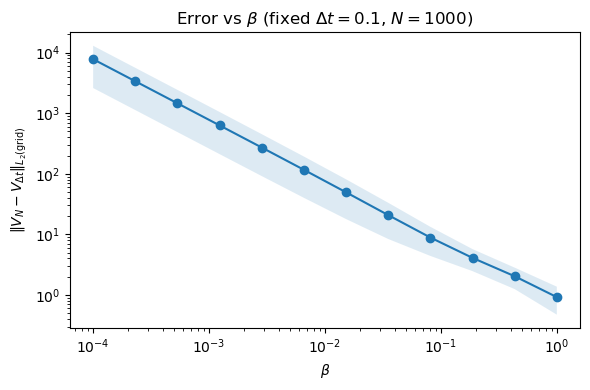

In [11]:
# ============================================================
# Fixed dt=0.1, N=100000, vary beta
# ============================================================

dt_fixed = 0.1
N_fixed = 1000

beta_grid = np.logspace(-4, 0, 12)   # from 0.01 to 1
rows_beta = []

for beta in beta_grid:
    print("=" * 70)
    print(f"Running beta={beta:.6f}, dt={dt_fixed}, N={N_fixed}")

    error_mean, error_std, _, _ = compute_error_for_one_setting(
        beta=beta,
        dt=dt_fixed,
        N_sample=N_fixed,
        n_rep=30,
        omega=omega,
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N_cost=N_cost,
        lambda_reg=lambda_reg,
        ridge=ridge,
        s_eval=np.linspace(-4.0, 4.0, 401),
        base_seed=12345,
    )

    rows_beta.append({
        "beta": beta,
        "dt": dt_fixed,
        "N_sample": N_fixed,
        "error_mean": error_mean,
        "error_std": error_std,
    })

    #print(f"error_mean={error_mean:.6e} | error_std={error_std:.6e}")

df_beta = pd.DataFrame(rows_beta)
#print(df_beta)

plt.figure(figsize=(6, 4))

plt.plot(
    df_beta["beta"],
    df_beta["error_mean"],
    marker="o"
)

plt.fill_between(
    df_beta["beta"],
    df_beta["error_mean"] - df_beta["error_std"],
    df_beta["error_mean"] + df_beta["error_std"],
    alpha=0.15
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\|V_N - V_{\Delta t}\|_{L_2(\mathrm{grid})}$")
plt.title(r"Error vs $\beta$ (fixed $\Delta t=0.1$, $N=1000$)")
plt.tight_layout()
plt.show()

Running beta=1.0, dt=0.010000, N=10000
Running beta=1.0, dt=0.016681, N=10000
Running beta=1.0, dt=0.027826, N=10000
Running beta=1.0, dt=0.046416, N=10000
Running beta=1.0, dt=0.077426, N=10000
Running beta=1.0, dt=0.129155, N=10000
Running beta=1.0, dt=0.215443, N=10000
Running beta=1.0, dt=0.359381, N=10000
Running beta=1.0, dt=0.599484, N=10000
Running beta=1.0, dt=1.000000, N=10000


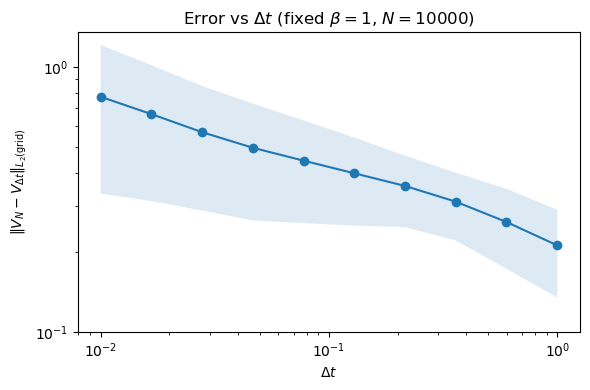

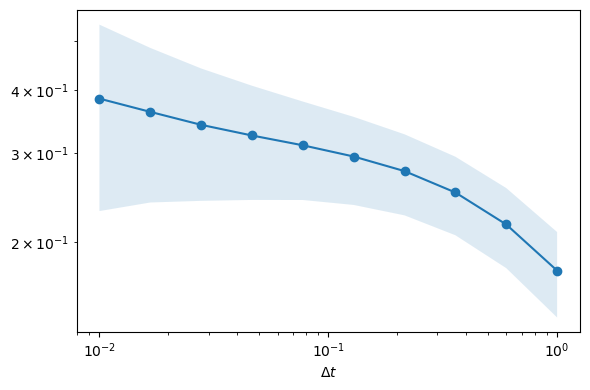

In [13]:
# ============================================================
# Fixed beta=1, N=1000, vary dt from 0.01 to 1
# ============================================================

beta_fixed = 1.0
N_fixed = 10000

dt_grid = np.logspace(-2, 0, 10)   
rows_dt = []

for dt in dt_grid:
    print("=" * 70)
    print(f"Running beta={beta_fixed}, dt={dt:.6f}, N={N_fixed}")

    error_mean, error_std, theta_mean, theta_std = compute_error_for_one_setting(
        beta=beta_fixed,
        dt=dt,
        N_sample=N_fixed,
        n_rep=100,
        omega=omega,
        A=A,
        B=B,
        sigma=sigma,
        M=M,
        N_cost=N_cost,
        lambda_reg=lambda_reg,
        ridge=ridge,
        s_eval=np.linspace(-4.0, 4.0, 401),
        base_seed=12345,
    )

    rows_dt.append({
        "beta": beta_fixed,
        "dt": dt,
        "N_sample": N_fixed,
        "error_mean": error_mean,
        "error_std": error_std,
        "theta_mean": theta_mean,
        "theta_std": theta_std,
    })

    #print(f"error_mean={error_mean:.6e} | error_std={error_std:.6e}")

df_dt = pd.DataFrame(rows_dt)
#print(df_dt)

plt.figure(figsize=(6, 4))

plt.plot(
    df_dt["dt"],
    df_dt["error_mean"],
    marker="o"
)

plt.fill_between(
    df_dt["dt"],
    df_dt["error_mean"] - df_dt["error_std"],
    df_dt["error_mean"] + df_dt["error_std"],
    alpha=0.15
)

plt.xscale("log")
plt.yscale("log")
plt.yticks([1e0, 1e-1], [r"$10^0$", r"$10^{-1}$"])
plt.xlabel(r"$\Delta t$")
plt.ylabel(r"$\|V_N - V_{\Delta t}\|_{L_2(\mathrm{grid})}$")
plt.title(r"Error vs $\Delta t$ (fixed $\beta=1$, $N=10000$)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))

plt.plot(
    df_dt["dt"],
    df_dt["theta_mean"],
    marker="o"
)

plt.fill_between(
    df_dt["dt"],
    df_dt["theta_mean"] - df_dt["theta_std"],
    df_dt["theta_mean"] + df_dt["theta_std"],
    alpha=0.15
)

plt.xscale("log")
plt.yscale("log")
#plt.yticks([1e0, 1e-1], [r"$10^0$", r"$10^{-1}$"])
plt.xlabel(r"$\Delta t$")
#plt.ylabel(r"$\|V_N - V_{\Delta t}\|_{L_2(\mathrm{grid})}$")
#plt.title(r"Error vs $\Delta t$ (fixed $\beta=1$, $N=10000$)")
plt.tight_layout()
plt.show()

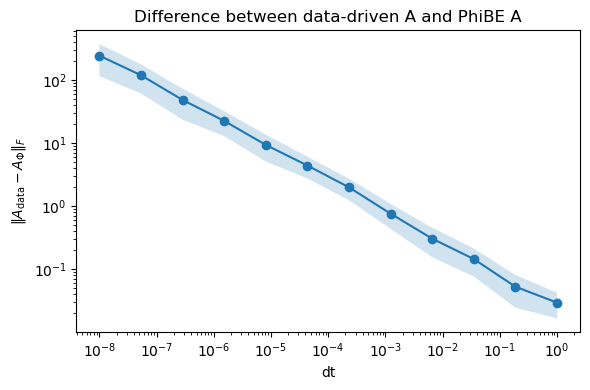

In [15]:
# ============================================================
# Fixed parameters
# ============================================================
omega = np.array([0.5, 1.0, 1.0])   # (w1, w2, w3)

A = -1.0
B = 1.0
sigma = 1

M = 1.0
N_cost = 1.0
lambda_reg = 0.1

ridge = 0.0
beta = 1.0

# ============================================================
# Basis
# ============================================================
def phi(s):
    return np.array([1.0 / beta, s, s**2])

def grad_phi(s):
    return np.array([0.0, 1.0, 2.0 * s])

# ============================================================
# Exact dt coefficients
# E[(S_{t+dt}-S_t)/dt | S_t=s, a] = A_dt s + B_dt a
# ============================================================
def exact_dt_coeffs(A, B, sigma, dt):
    A_dt = (np.exp(A * dt) - 1.0) / dt

    if abs(A) < 1e-12:
        B_dt = B
        sigma_t2 = sigma**2
        expA = 1.0
        var_noise = sigma**2 * dt
    else:
        B_dt = B * (np.exp(A * dt) - 1.0) / (A * dt)
        sigma_t2 = sigma**2 * (np.exp(2.0 * A * dt) - 1.0) / (2.0 * A * dt)
        expA = np.exp(A * dt)
        var_noise = sigma**2 * (np.exp(2.0 * A * dt) - 1.0) / (2.0 * A)

    return A_dt, B_dt, sigma_t2, expA, var_noise

# ============================================================
# Policy: a ~ N(w1 s + w2, w3^2)
# ============================================================
def sample_action(s, omega, rng):
    w1, w2, w3 = omega
    return rng.normal(loc=w1 * s + w2, scale=w3)

# ============================================================
# One-step on-policy samples
# trajectory length = 1
# ============================================================
def sample_one_step_data(n_samples, dt, omega, A, B, sigma, rng):
    w1, w2, w3 = omega
    A_dt, B_dt, sigma_t2, expA, var_noise = exact_dt_coeffs(A, B, sigma, dt)

    # choose initial states from a fixed distribution
    #s = rng.normal(loc=0.0, scale=1.0, size=n_samples)
    s = rng.uniform(low=-1.0, high=1.0, size=n_samples)
    a = np.array([sample_action(si, omega, rng) for si in s])

    # exact one-step transition
    noise = rng.normal(loc=0.0, scale=np.sqrt(var_noise), size=n_samples)
    s_next = expA * s + (dt * B_dt) * a + noise

    return s, a, s_next

# ============================================================
# A_data:
# 1/N sum phi(s) ( beta phi(s) - ((s'-s)/dt) grad_phi(s) )^T
# ============================================================
def create_A_data(beta, s, s_next, dt):
    A_data = np.zeros((3, 3))
    n = len(s)

    for i in range(n):
        si = s[i]
        spi = s_next[i]

        basis = phi(si)
        g_basis = grad_phi(si)

        incr_over_dt = (spi - si) / dt
        term = - beta * basis + incr_over_dt * g_basis

        A_data += np.outer(basis, term)

    A_data /= n
    return A_data

# ============================================================
# A_phibe:
# 1/N sum phi(s) ( beta phi(s) - mu_dt(s) grad_phi(s) )^T
# where mu_dt(s) = A_dt s + B_dt E[a|s]
# ============================================================
def create_A_phibe(beta, A, B, omega, s, dt):
    w1, w2, w3 = omega
    A_dt, B_dt, sigma_t2, expA, var_noise = exact_dt_coeffs(A, B, sigma, dt)

    A_phibe = np.zeros((3, 3))
    n = len(s)

    for si in s:
        basis = phi(si)
        g_basis = grad_phi(si)

        mu_a = w1 * si + w2
        mu_dt = A_dt * si + B_dt * mu_a

        term = - beta * basis + mu_dt * g_basis
        A_phibe += np.outer(basis, term)

    A_phibe /= n
    return A_phibe

# ============================================================
# Run experiment over dt grid
# ============================================================
def run_A_diff_experiment(
    dt_grid,
    n_samples=5000,
    n_rep=20,
    seed=123
):
    rows = []
    master_rng = np.random.default_rng(seed)

    for dt in dt_grid:
        diffs = []

        for rep in range(n_rep):
            rng = np.random.default_rng(master_rng.integers(1_000_000_000))

            s, a, s_next = sample_one_step_data(
                n_samples=n_samples,
                dt=dt,
                omega=omega,
                A=A,
                B=B,
                sigma=sigma,
                rng=rng
            )

            A_data = create_A_data(beta=beta, s=s, s_next=s_next, dt=dt)
            A_phibe = create_A_phibe(beta=beta, A=A, B=B, omega=omega, s=s, dt=dt)

            diff = np.linalg.norm(A_data - A_phibe, ord='fro')
            diffs.append(diff)

        rows.append({
            "dt": dt,
            "A_diff_mean": np.mean(diffs),
            "A_diff_std": np.std(diffs),
        })

    return pd.DataFrame(rows)

# ============================================================
# Example run
# ============================================================
dt_grid = np.logspace(-8, 0, 12)  
df_A = run_A_diff_experiment(
    dt_grid=dt_grid,
    n_samples=5000,
    n_rep=20,
    seed=42
)

#print(df_A)

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(6, 4))
plt.plot(df_A["dt"], df_A["A_diff_mean"], marker="o")
plt.fill_between(
    df_A["dt"],
    df_A["A_diff_mean"] - df_A["A_diff_std"],
    df_A["A_diff_mean"] + df_A["A_diff_std"],
    alpha=0.2
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("dt")
plt.ylabel(r"$\|A_{\mathrm{data}} - A_{\Phi}\|_F$")
plt.title("Difference between data-driven A and PhiBE A")
plt.tight_layout()
plt.show()